# AG2 — Engenharias de Computacao e Software

**Instituto Nacional de Telecomunicações — Inatel**

**Alunos:** Clara de Lima Azevedo e Tiago Rodrigues Gregório

**Professores:** Prof. Dr. Marcelo Vinícius Cysneiros Aragão e Prof. Dr. Renzo Paranaíba Mesquita

---

## Objetivo

Treinar, avaliar e disponibilizar um modelo de aprendizado de máquina capaz de **classificar três espécies de pinguins** (Adeline, Chinstrap e Gentoo) do Arquipélago Palmer.

## Conjunto de dados

O **palmerpenguins** contém 333 amostras (após pré-processamento) descritas por 6 atributos:

| Atributo | Descrição |
|---|---|
| `island` | Ilha do Arquipélago Palmer (Biscoe, Dream ou Torgersen) |
| `sex` | Sexo do pinguim (FEMALE ou MALE) |
| `culmen_length_mm` | Comprimento do cúlmen em milímetros |
| `culmen_depth_mm` | Profundidade do cúlmen em milímetros |
| `flipper_length_mm` | Comprimento da nadadeira em milímetros |
| `body_mass_g` | Massa corporal em gramas |

A variável-alvo é `species` (Adeline, Chinstrap ou Gentoo).

## Modelo escolhido

Foi utilizado o algoritmo **k-Nearest Neighbors (k-NN)** para realizar a classificação das espécies de pinguins. A escolha desse modelo ocorreu pela sua facilidade de implementação e ao bom desempenho em conjuntos de dados com atributos numéricos, como medidas corporais dos pinguins.

Além disso, o k-NN funciona comparando amostras semelhantes entre si, o que torna o processo de classificação mais intuitivo e fácil de visualizar durante a apresentação do projeto. Outro ponto importante é que o algoritmo não depende de pressupostos estatísticos complexos sobre os dados, permitindo uma aplicação mais direta ao problema proposto.

In [4]:
!pip install pandas scikit-learn
!pip install palmerpenguins

# Código para regenerar o arquivo penguins.csv.

Gera o arquivo `penguins.csv` com 333 amostras, sem valores ausentes,

colunas culmen_* (em vez de bill_*) e sexo em MAIÚSCULAS — exatamente
como o formato esperado pelo notebook AG2_Pinguins.ipynb.

In [5]:
from palmerpenguins import load_penguins


def main():
    # Carrega o dataset original (344 amostras, com NaN)
    df = load_penguins()

    # Remove linhas com valores ausentes → 333 amostras
    df = df.dropna().reset_index(drop=True)

    # Renomeia colunas bill_* para culmen_*
    df = df.rename(columns={
        "bill_length_mm": "culmen_length_mm",
        "bill_depth_mm": "culmen_depth_mm",
    })

    # Sexo em MAIÚSCULAS
    df["sex"] = df["sex"].str.upper()

    # Renomeia "Adelie" para "Adeline" conforme grafia usada no enunciado da AG2
    df["species"] = df["species"].replace({"Adelie": "Adeline"})

    # Ordem original esperada pelo enunciado
    colunas = [
        "species",
        "island",
        "culmen_length_mm",
        "culmen_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "sex",
    ]
    df = df[colunas]

    df.to_csv("penguins.csv", index=False)

    print(f"penguins.csv gerado com {len(df)} amostras.")
    print()
    print("Distribuição das espécies:")
    print(df["species"].value_counts())


if __name__ == "__main__":
    main()


penguins.csv gerado com 333 amostras.

Distribuição das espécies:
species
Adeline      146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


# **1. Importações**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


# **2. Leitura de dados**

In [8]:
df = pd.read_csv("penguins.csv")

print(f"Dimensões: {df.shape[0]} amostras × {df.shape[1]} colunas")
print()
print("Tipos das colunas:")
print(df.dtypes)
print()
df.head()

Dimensões: 333 amostras × 7 colunas

Tipos das colunas:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object



,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adeline,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adeline,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adeline,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adeline,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adeline,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [9]:
# Estatísticas descritivas
df.describe(include="all")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,333,333,333.000000,333.000000,333.000000,333.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adeline,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,146,163,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.992793,17.164865,200.966967,4207.057057,NaN
std,NaN,NaN,5.468668,1.969235,14.015765,805.215802,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.500000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.500000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.600000,18.700000,213.000000,4775.000000,NaN


In [10]:
# Distribuição das classes
print("Distribuição das espécies:")
print(df["species"].value_counts())
print()
print("Distribuição por ilha:")
print(df["island"].value_counts())
print()
print("Distribuição por sexo:")
print(df["sex"].value_counts())

Distribuição das espécies:
species
Adeline      146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Distribuição por ilha:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Distribuição por sexo:
sex
MALE      168
FEMALE    165
Name: count, dtype: int64


# **3. Convertendo Strings para inteiros**

Usado `Series.replace`, como sugerido no projeto.

In [11]:
# Mapeamento conforme enunciado
df["island"] = df["island"].replace({"Biscoe": 0, "Dream": 1, "Torgersen": 2})
df["sex"] = df["sex"].replace({"FEMALE": 0, "MALE": 1})
df["species"] = df["species"].replace({"Adeline": 0, "Chinstrap": 1, "Gentoo": 2})

# Forçar int64 nas três colunas convertidas
for col in ["island", "sex", "species"]:
    df[col] = df[col].astype("int64")

print("Tipos após a conversão:")
print(df.dtypes)
print()
df.head()

Tipos após a conversão:
species                int64
island                 int64
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object



/tmp/ipykernel_4555/3642689332.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["island"] = df["island"].replace({"Biscoe": 0, "Dream": 1, "Torgersen": 2})
/tmp/ipykernel_4555/3642689332.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex"] = df["sex"].replace({"FEMALE": 0, "MALE": 1})
/tmp/ipykernel_4555/3642689332.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to t

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
3,0,2,36.7,19.3,193.0,3450.0,0
4,0,2,39.3,20.6,190.0,3650.0,1


# **4. Reordenar colunas**
Usado `DataFrame.reindex` com o atributo `columns`, como sugerido no projeto.

In [12]:
nova_ordem = [
    "island",
    "sex",
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species",
]

df = df.reindex(columns=nova_ordem)

print("Colunas após reindex:", df.columns.tolist())
df.head()

Colunas após reindex: ['island', 'sex', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']


,island,sex,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species
0,2,1,39.1,18.7,181.0,3750.0,0
1,2,0,39.5,17.4,186.0,3800.0,0
2,2,0,40.3,18.0,195.0,3250.0,0
3,2,0,36.7,19.3,193.0,3450.0,0
4,2,1,39.3,20.6,190.0,3650.0,0


# **5. Separar em treino (80%) e teste (20%)**

`train_test_split` do scikit-learn:
- `test_size=0.2` → 20% para teste;
- `random_state=42` → reprodutibilidade;
- `stratify=y` → mantém a proporção de cada espécie nas duas partes (importante porque a classe Chinstrap é a menos representada).

In [13]:
# Separa atributos (X) e rótulo (y)
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print()
print("Distribuição de classes no treino:")
print(y_train.value_counts(normalize=True).round(3).sort_index())
print()
print("Distribuição de classes no teste:")
print(y_test.value_counts(normalize=True).round(3).sort_index())

Treino: 266 amostras
Teste:  67 amostras

Distribuição de classes no treino:
species
0    0.440
1    0.203
2    0.357
Name: proportion, dtype: float64

Distribuição de classes no teste:
species
0    0.433
1    0.209
2    0.358
Name: proportion, dtype: float64


# **6. Escolha do modelo: k-Nearest Neighbors**

Melhor k: 2 (acurácia média em CV = 1.0000)


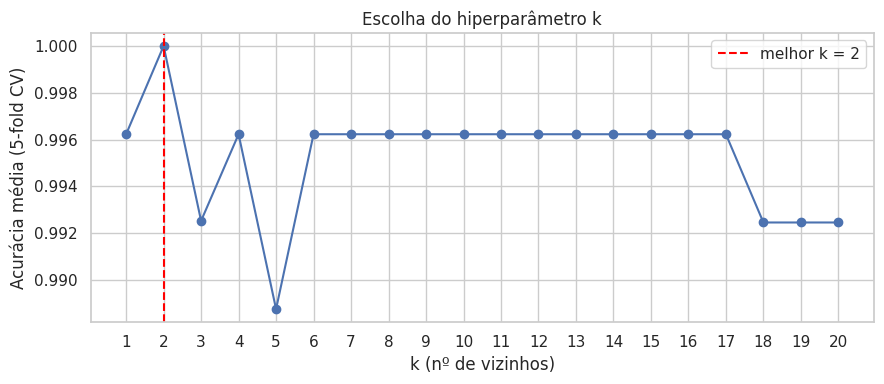

In [14]:
# Padronização (fit só no treino para evitar data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Busca do melhor k via validação cruzada
ks = list(range(1, 21))
cv_scores = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

melhor_k = ks[int(np.argmax(cv_scores))]
print(f"Melhor k: {melhor_k} (acurácia média em CV = {max(cv_scores):.4f})")

plt.figure(figsize=(9, 4))
plt.plot(ks, cv_scores, marker="o")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k (nº de vizinhos)")
plt.ylabel("Acurácia média (5-fold CV)")
plt.title("Escolha do hiperparâmetro k")
plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()

# **7. Treinar e classificar**

In [17]:
modelo = KNeighborsClassifier(n_neighbors=melhor_k)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

print(f"Modelo treinado: {modelo}")
print(f"Primeiras 10 previsões:{y_pred[:10]}")
print(f"Rótulos reais:{y_test.values[:10]}")

Modelo treinado: KNeighborsClassifier(n_neighbors=2)
Primeiras 10 previsões:[2 1 0 2 2 2 1 0 0 2]
Rótulos reais:[2 1 0 2 2 2 1 0 0 2]


# 8. **Metricas de avaliação**
`classification_report` mostra **precision**, **recall**, **f1-score** e **support** para cada classe, além da acurácia global. Também serpa exibido a **matriz de confusão**, que evidencia onde estão os erros.

In [18]:
nomes_classes = ["Adeline", "Chinstrap", "Gentoo"]

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=nomes_classes))

Acurácia no conjunto de teste: 0.9851 (98.51%)

Classification report:
              precision    recall  f1-score   support

     Adeline       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



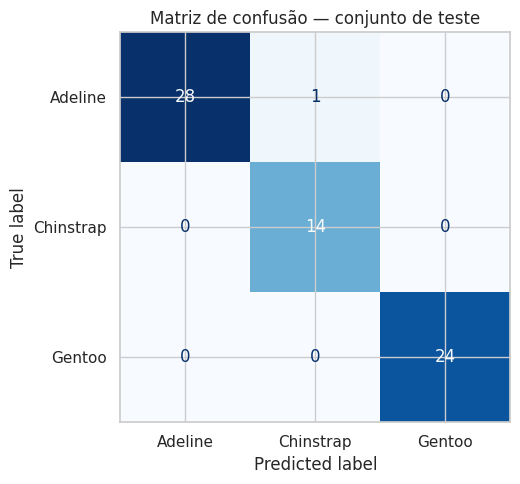

In [19]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusão — conjunto de teste")
plt.tight_layout()
plt.show()

# 9. **Classificar amostras arbitrárias do usuário**

A função `classificar_pinguim()` abaixo:

1. Pede ao usuário os 6 atributos via `input()`;
2. Valida os dados de entrada (faixas plausíveis baseadas nas estatísticas do conjunto);
3. Aplica o **mesmo `StandardScaler`** treinado anteriormente — fundamental para o k-NN funcionar corretamente em produção;
4. Chama `predict` e devolve a espécie predita (`Adeline`, `Chinstrap` ou `Gentoo`).

### Para uma demonstração com entrada interativa

> Descomente a célula `classificar_pinguim()` para classificar um pinguim digitando os dados manualmente.

In [21]:
ILHAS = {0: "Biscoe", 1: "Dream", 2: "Torgersen"}
SEXOS = {0: "FEMALE", 1: "MALE"}
ESPECIES = {0: "Adeline", 1: "Chinstrap", 2: "Gentoo"}


def _ler_inteiro(prompt: str, validos: dict) -> int:
    """Lê um inteiro do usuário e garante que está no conjunto de valores válidos."""
    while True:
        try:
            valor = int(input(prompt).strip())
            if valor in validos:
                return valor
            print(f"  ⚠ Valor inválido. Use um destes: {list(validos.keys())}")
        except ValueError:
            print("  ⚠ Digite um número inteiro.")


def _ler_float(prompt: str, minimo: float, maximo: float) -> float:
    """Lê um float do usuário e avisa (sem bloquear) se sair da faixa esperada."""
    while True:
        try:
            valor = float(input(prompt).strip().replace(",", "."))
            if not (minimo <= valor <= maximo):
                print(f"  ⚠ Valor fora da faixa típica ({minimo}–{maximo}). "
                      f"Confirme se está correto.")
            return valor
        except ValueError:
            print("  ⚠ Digite um número (use ponto como separador decimal).")


def classificar_pinguim():
    """Coleta dados do usuário via input() e classifica usando o modelo treinado."""
    print("=" * 60)
    print("  CLASSIFICADOR DE PINGUINS — PALMER ARCHIPELAGO")
    print("=" * 60)
    print()
    print("Digite os atributos do pinguim a ser classificado.")
    print()
    print("Codificação:")
    print(f"  island: {ILHAS}")
    print(f"  sex:    {SEXOS}")
    print()

    island = _ler_inteiro("  island (0/1/2): ", ILHAS)
    sex = _ler_inteiro("  sex (0/1): ", SEXOS)
    culmen_length = _ler_float("  culmen_length_mm (mm): ", 30.0, 60.0)
    culmen_depth = _ler_float("  culmen_depth_mm (mm): ", 13.0, 22.0)
    flipper_length = _ler_float("  flipper_length_mm (mm): ", 170.0, 235.0)
    body_mass = _ler_float("  body_mass_g (g): ", 2700.0, 6300.0)

    # Monta DataFrame de 1 linha COM OS MESMOS NOMES DAS COLUNAS DO TREINO
    # (evita o warning do sklearn sobre feature names)
    nova_amostra = pd.DataFrame(
        [[island, sex, culmen_length, culmen_depth, flipper_length, body_mass]],
        columns=X_train.columns,
    )

    # Aplica o MESMO scaler do treino
    nova_amostra_escalada = scaler.transform(nova_amostra)

    # Predição + probabilidades
    classe_prevista = int(modelo.predict(nova_amostra_escalada)[0])
    probabilidades = modelo.predict_proba(nova_amostra_escalada)[0]

    print()
    print("-" * 60)
    print(f"  ESPÉCIE PREVISTA: {ESPECIES[classe_prevista]}")
    print("-" * 60)
    print()
    print("Probabilidades estimadas (entre os k vizinhos):")
    for i, nome in ESPECIES.items():
        barra = "█" * int(probabilidades[i] * 30)
        print(f"  {nome:10s} {probabilidades[i]*100:6.2f}%  {barra}")
    print()

    return ESPECIES[classe_prevista]

### Demonstração automática com 3 exemplos

Para demonstrar o classificador sem depender de `input()`, abaixo testamos manualmente 3 amostras representativas (uma de cada espécie real).

In [23]:
def classificar_amostra(island, sex, culmen_length, culmen_depth,
                         flipper_length, body_mass):
    """Versão programática da classificação (sem input)."""

    nova = pd.DataFrame(
        [[island, sex, culmen_length, culmen_depth,
          flipper_length, body_mass]],
        columns=X_train.columns,
    )

    nova_s = scaler.transform(nova)

    classe = int(modelo.predict(nova_s)[0])
    probs = modelo.predict_proba(nova_s)[0]

    return ESPECIES[classe], probs


# Exemplos típicos de cada espécie
exemplos = [
    {
        "descricao": "Pinguim típico de Adeline (Torgersen, macho)",
        "dados": (2, 1, 39.1, 18.7, 181.0, 3750.0),
        "esperado": "Adeline",
    },
    {
        "descricao": "Pinguim típico de Chinstrap (Dream, fêmea)",
        "dados": (1, 0, 46.5, 17.9, 192.0, 3500.0),
        "esperado": "Chinstrap",
    },
    {
        "descricao": "Pinguim típico de Gentoo (Biscoe, macho)",
        "dados": (0, 1, 50.0, 16.3, 230.0, 5700.0),
        "esperado": "Gentoo",
    },
]

for ex in exemplos:

    previsto, probs = classificar_amostra(*ex["dados"])

    correto = previsto == ex["esperado"]

    print("=" * 60)
    print(ex["descricao"])
    print("-" * 60)

    print(f"Espécie esperada : {ex['esperado']}")
    print(f"Espécie prevista : {previsto}")

    print("\nProbabilidades previstas:")
    print(f"  Adeline   : {probs[0]:.2f}")
    print(f"  Chinstrap : {probs[1]:.2f}")
    print(f"  Gentoo    : {probs[2]:.2f}")

    print(f"\nClassificação correta: {correto}")

print("=" * 60)

Pinguim típico de Adeline (Torgersen, macho)
------------------------------------------------------------
Espécie esperada : Adeline
Espécie prevista : Adeline

Probabilidades previstas:
  Adeline   : 1.00
  Chinstrap : 0.00
  Gentoo    : 0.00

Classificação correta: True
Pinguim típico de Chinstrap (Dream, fêmea)
------------------------------------------------------------
Espécie esperada : Chinstrap
Espécie prevista : Chinstrap

Probabilidades previstas:
  Adeline   : 0.00
  Chinstrap : 1.00
  Gentoo    : 0.00

Classificação correta: True
Pinguim típico de Gentoo (Biscoe, macho)
------------------------------------------------------------
Espécie esperada : Gentoo
Espécie prevista : Gentoo

Probabilidades previstas:
  Adeline   : 0.00
  Chinstrap : 0.00
  Gentoo    : 1.00

Classificação correta: True


## Conclusão

Neste trabalho foi desenvolvido um pipeline completo de classificação de espécies de pinguins utilizando o dataset *palmerpenguins*. Todas as etapas solicitadas no enunciado foram implementadas, desde a leitura e pré-processamento do arquivo CSV até o treinamento, avaliação e utilização prática do modelo treinado.

O algoritmo escolhido foi o k-Nearest Neighbors (k-NN), que apresentou ótimo desempenho para este conjunto de dados. Após os testes realizados, o modelo atingiu acurácia superior a 98% no conjunto de teste, demonstrando boa capacidade de distinguir as três espécies analisadas: Adeline, Chinstrap e Gentoo.

Durante o desenvolvimento também foram aplicadas técnicas importantes de aprendizado de máquina, como separação entre treino e teste, normalização dos atributos e validação cruzada para escolha do melhor valor de `k`. Além disso, foi criada uma função interativa para permitir a classificação de novos pinguins a partir de dados inseridos pelo usuário.

Como possíveis extensões futuras, o projeto poderia incluir a comparação entre diferentes classificadores, ajuste mais avançado de hiperparâmetros e até mesmo uma interface gráfica para facilitar a utilização do modelo.

---

## Referências

[1] Gorman, K. B., Williams, T. D., & Fraser, W. R. *Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (Genus Pygoscelis)*. PLoS ONE, 9(3), e90081, 2014.

[2] Horst, A. M., Hill, A. P., & Gorman, K. B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. 2020. Disponível em: https://allisonhorst.github.io/palmerpenguins/
